In [68]:
import cv2 as cv
import numpy as np
from math import hypot
import matplotlib.pyplot as plt
from random import sample


(2.5, 0.0),
(2.5, 2.0),
(2.5, 6.0),
(0.5, 1.0),
(2.5, 8.0),
(1.5, 3.0),
(1.5, 7.0),
(2.5, 10.0),
(0.5, 4.0),
(2.5, 12.0),
(1.5, 5.0),
(0.5, 9.0),
(1.5, 14.0),
(0.5, 11.0),
(0.5, 13.0),
(1.5, 15.0),


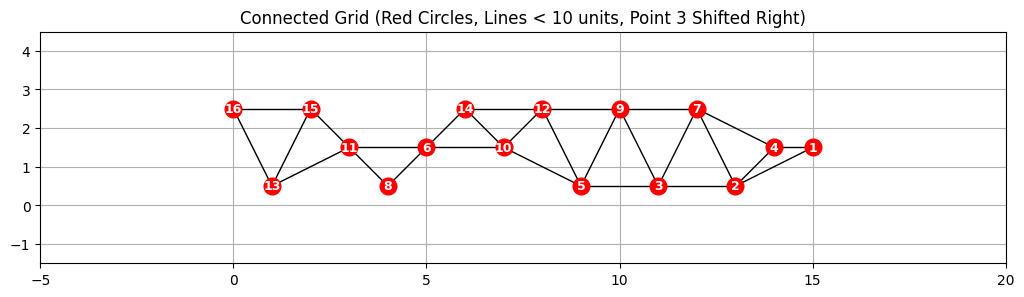

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Your input points
points = np.array([
    [1495, 805],
    [1380, 690],
    [1150, 690],
    [1495, 575],
    [1035, 575],
    [1380, 575],
    [1150, 460],
    [920, 460],
    [1380, 460],
    [805, 460],
    [1265, 575],
    [1035, 345],
    [690, 345],
    [920, 345],
    [805, 230],
    [575, 230]
])


# Rotate using PCA to flatten the data
mean = np.mean(points, axis=0)
centered = points - mean
cov = np.cov(centered, rowvar=False)
eigvals, eigvecs = np.linalg.eig(cov)
main_dir = eigvecs[:, np.argmax(eigvals)]
angle = np.arctan2(main_dir[1], main_dir[0])

rotation_matrix = np.array([
    [np.cos(-angle), -np.sin(-angle)],
    [np.sin(-angle),  np.cos(-angle)]
])
rotated = (rotation_matrix @ centered.T).T

# Normalize to grid (3 rows)
y_vals = rotated[:, 1]
y_ranks = np.argsort(y_vals)
rows = np.zeros_like(y_vals, dtype=int)

third = len(y_vals) // 3
rows[y_ranks[:third]] = 2
rows[y_ranks[third:2*third]] = 1
rows[y_ranks[2*third:]] = 0

x_vals = rotated[:, 0]
x_sorted = np.argsort(x_vals)
columns = np.zeros_like(x_vals, dtype=int)
col_pos = 0
prev_x = x_vals[x_sorted[0]]
scale = 20

for i in range(len(x_sorted)):
    idx = x_sorted[i]
    if i > 0 and abs(x_vals[idx] - prev_x) > scale:
        col_pos += 1
        prev_x = x_vals[idx]
    columns[idx] = col_pos

# Flip horizontally
max_col = columns.max()
columns = max_col - columns


# Scale coordinates by 4.5
scaled_rows = (2.5 - rows)# flip vertically (top row is 0)
scaled_cols = columns 

positions = np.stack((scaled_cols, scaled_rows), axis=1)

for idx, (r, c) in enumerate(zip(scaled_rows, scaled_cols), start=1):
    print(f"({r:.1f}, {c:.1f}),")

# Plotting
fig, ax = plt.subplots(figsize=(12, 3))


threshold = 2.5  # distance threshold
for i in range(len(positions)):
    for j in range(i + 1, len(positions)):
        dist = np.linalg.norm(positions[i] - positions[j])
        if dist < threshold:
            x_values = [positions[i][0], positions[j][0]]
            y_values = [positions[i][1], positions[j][1]]
            ax.plot(x_values, y_values, 'k-', linewidth=1)

for idx, (x, y) in enumerate(positions, start=1):
    ax.plot(x, y, 'ro', markersize=12)
    ax.text(x, y, str(17 - idx), ha='center', va='center', fontsize=9, color='white', weight='bold')

ax.set_xlim(min(scaled_cols) - 5, max(scaled_cols) + 5)
ax.set_ylim(min(scaled_rows) - 2, max(scaled_rows) + 2)
ax.set_aspect('equal')
ax.grid(True)

plt.title("Connected Grid")
plt.tight_layout()
plt.show()




In [70]:
import cv2 as cv
import numpy as np
from math import hypot

# Load and preprocess image
image = cv.imread('C:/Users/gusro/OneDrive/Desktop/YQH/YQC-2025/city.png') 
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
_, thresh = cv.threshold(gray, 239, 255, cv.THRESH_BINARY)
kernel = np.ones((11, 5), np.uint8)
thresh = cv.dilate(thresh, kernel, iterations=1)
inverted_image = cv.bitwise_not(thresh)

# Find contours
contours, _ = cv.findContours(inverted_image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
circles_image = image.copy()

# Bounds
upper_x = 2000 
upper_y = 1000  
lower_x = 0    
lower_y = 100    

# Collect valid centers
centers = []

for contour in contours:
    epsilon = 0.02 * cv.arcLength(contour, True)
    approx = cv.approxPolyDP(contour, epsilon, True)

    if len(approx) >= 3:
        x, y, w, h = cv.boundingRect(approx)
        area = w * h

        if area <= 10000:
            center_x = x + w // 2
            center_y = y + h // 2

            if ( # Masks
                lower_x <= center_x <= upper_x and
                lower_y <= center_y <= upper_y and
                not (center_x > 1200 and center_y < 450) and 
                not (center_x > 900 and center_y < 200) and 
                not (center_x > 1500 and center_y < 500) and
                not center_y < 150 and 
                not center_x < 500 and
                not (center_x < 600 and center_y > 400)
            ):
                centers.append((center_x, center_y))

# Group points by proximity
def group_close_points(points, radius):
    groups = []
    used = [False] * len(points)

    for i, pt in enumerate(points):
        if used[i]:
            continue
        group = [pt]
        used[i] = True
        for j, other in enumerate(points):
            if not used[j] and hypot(pt[0] - other[0], pt[1] - other[1]) <= radius:
                group.append(other)
                used[j] = True
        groups.append(group)
    return groups

# Group and calculate averaged centers
radius = 160
groups = group_close_points(centers, radius)

averaged_centers = []
counter = 0
for group in groups:
    avg_x = int(sum(p[0] for p in group) / len(group))
    avg_y = int(sum(p[1] for p in group) / len(group))
    averaged_centers.append((avg_x, avg_y))
    counter += 1

# Draw connecting lines first
connect_radius = 230
for i, (x1, y1) in enumerate(averaged_centers):
    for j, (x2, y2) in enumerate(averaged_centers):
        if i < j and hypot(x1 - x2, y1 - y2) <= connect_radius:
            cv.line(circles_image, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Blue line

# Then draw the circles (so they appear on top)
for idx, (avg_x, avg_y) in enumerate(averaged_centers):
    cv.circle(circles_image, (avg_x, avg_y), 7, (0, 0, 255), -1)  # Red circle
    cv.putText(circles_image, str(idx + 1), (avg_x + 10, avg_y - 10), cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

# Display final result
cv.namedWindow('Averaged Circles + Lines', cv.WINDOW_NORMAL)
resized_output = cv.resize(circles_image, None, fx=1.0, fy=1.0)
cv.imshow('Averaged Circles + Lines', resized_output)

print(f"Total averaged circles: {counter}")

cv.waitKey(0)
cv.destroyAllWindows()



Total averaged circles: 16


In [71]:
import cv2 as cv
import numpy as np
from math import hypot, sqrt

# Load and preprocess image
image = cv.imread('C:/Users/gusro/OneDrive/Desktop/YQH/YQC-2025/city.png') 
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
_, thresh = cv.threshold(gray, 239, 255, cv.THRESH_BINARY)
kernel = np.ones((11, 5), np.uint8)
thresh = cv.dilate(thresh, kernel, iterations=1)
inverted_image = cv.bitwise_not(thresh)

# Find contours
contours, _ = cv.findContours(inverted_image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
circles_image = image.copy()

# Bounds
upper_x = 2000 
upper_y = 1000  
lower_x = 0    
lower_y = 100    

# Collect valid centers
raw_centers = []

for contour in contours:
    epsilon = 0.02 * cv.arcLength(contour, True)
    approx = cv.approxPolyDP(contour, epsilon, True)

    if len(approx) >= 3:
        x, y, w, h = cv.boundingRect(approx)
        area = w * h

        if area <= 10000:
            center_x = x + w // 2
            center_y = y + h // 2

            if (
                lower_x <= center_x <= upper_x and
                lower_y <= center_y <= upper_y and
                not (center_x > 1200 and center_y < 450) and 
                not (center_x > 900 and center_y < 200) and 
                not (center_x > 1500 and center_y < 500) and
                not center_y < 150 and 
                not center_x < 500 and
                not (center_x < 600 and center_y > 400)
            ):
                raw_centers.append((center_x, center_y))

# Group points by proximity
def group_close_points(points, radius):
    groups = []
    used = [False] * len(points)

    for i, pt in enumerate(points):
        if used[i]:
            continue
        group = [pt]
        used[i] = True
        for j, other in enumerate(points):
            if not used[j] and hypot(pt[0] - other[0], pt[1] - other[1]) <= radius:
                group.append(other)
                used[j] = True
        groups.append(group)
    return groups

# Initial grouping to get rough centers
radius = 160
groups = group_close_points(raw_centers, radius)

initial_centers = []
for group in groups:
    avg_x = int(sum(p[0] for p in group) / len(group))
    avg_y = int(sum(p[1] for p in group) / len(group))
    initial_centers.append((avg_x, avg_y))

grid_spacing = 115

# Snap a point to nearest grid position
def snap_to_grid(point, spacing):
    x, y = point
    grid_x = round(x / spacing) * spacing
    grid_y = round(y / spacing) * spacing
    return (grid_x, grid_y)

# Snap and remove duplicates
grid_centers = []
for center in initial_centers:
    grid_pos = snap_to_grid(center, grid_spacing)
    if grid_pos not in grid_centers:
        grid_centers.append(grid_pos)

# Shift point 11 (index 10) down by one grid spacing
grid_centers[10] = (grid_centers[10][0], grid_centers[10][1] + grid_spacing)

# Print all final grid coordinates
print("\nFinal Grid Coordinates:")
for idx, (x, y) in enumerate(grid_centers, start=1):
    print(f"Point {idx:<2}: ({x}, {y})")

# Draw connections (grid-aligned)
for i, (x1, y1) in enumerate(grid_centers):
    for j, (x2, y2) in enumerate(grid_centers):
        if i < j:
            dx = abs(x1 - x2)
            dy = abs(y1 - y2)
            
            # Horizontal/vertical
            if (dx == grid_spacing and dy == 0) or (dx == 0 and dy == grid_spacing):
                cv.line(circles_image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            # Diagonal (√2 spacing)
            elif dx == grid_spacing and dy == grid_spacing:
                distance = hypot(dx, dy)
                expected = grid_spacing * sqrt(2)
                if abs(distance - expected) < 0.1:
                    cv.line(circles_image, (x1, y1), (x2, y2), (255, 0, 0), 2)

# Draw circles and labels
for idx, (x, y) in enumerate(grid_centers):
    cv.circle(circles_image, (x, y), 7, (0, 0, 255), -1)
    cv.putText(circles_image, str(idx + 1), (x + 10, y - 10),
               cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

# Show result
cv.namedWindow('Equidistant Circles + Lines', cv.WINDOW_NORMAL)
resized_output = cv.resize(circles_image, None, fx=1.0, fy=1.0)
cv.imshow('Equidistant Circles + Lines', resized_output)

print(f"\nTotal equidistant circles: {len(grid_centers)}")

cv.waitKey(0)
cv.destroyAllWindows()



Final Grid Coordinates:
Point 1 : (1495, 805)
Point 2 : (1380, 690)
Point 3 : (1150, 690)
Point 4 : (1495, 575)
Point 5 : (1035, 575)
Point 6 : (1380, 575)
Point 7 : (1150, 460)
Point 8 : (920, 460)
Point 9 : (1380, 460)
Point 10: (805, 460)
Point 11: (1265, 575)
Point 12: (1035, 345)
Point 13: (690, 345)
Point 14: (920, 345)
Point 15: (805, 230)
Point 16: (575, 230)

Total equidistant circles: 16


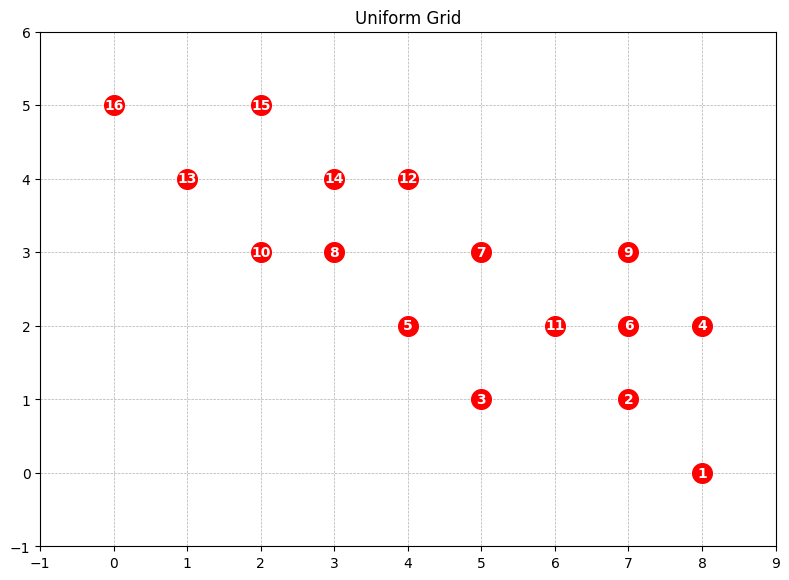

In [73]:
import matplotlib.pyplot as plt

# Your list of grid points
points = [
    (8, 0), (7, 1), (5, 1), (8, 2), (4, 2), (7, 2),
    (5, 3), (3, 3), (7, 3), (2, 3), (6, 2), (4, 4),
    (1, 4), (3, 4), (2, 5), (0, 5)
]
# Extract X and Y coordinates
x_coords, y_coords = zip(*points)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_coords, y_coords, color='red', s=200, zorder=2)

# Annotate each point with consistent label size
for i, (x, y) in enumerate(points, start=1):
    plt.text(x, y, str(i), ha='center', va='center', fontsize=10, color='white',
             weight='bold', zorder=3)

# Make grid and layout consistent
plt.gca().set_aspect('equal')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(min(x_coords)-1, max(x_coords)+2))
plt.yticks(range(min(y_coords)-1, max(y_coords)+2))
plt.title("Uniform Grid")
plt.tight_layout()
plt.show()
